# Module 5: Fraud Detection (E-Commerce)

Core Objective: Identify and flag fraudulent transactions.


In [1]:
import os
import json

# 1. Create the .kaggle directory
!mkdir -p ~/.kaggle

# 2. Manually write the kaggle.json file
# Replace 'your_username' with your actual Kaggle handle
# Replace 'your_token' with that long KGAT_... string
data = {
    "username": "grimmjo0",
    "key": "KGAT_c06cd3a2b9f9d3ba79e2950a5652f266"
}

with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(data, f)

# 3. Set permissions (CRITICAL: Kaggle will ignore the file without this)
!chmod 600 ~/.kaggle/kaggle.json

# 4. Test the connection
!kaggle datasets list -s "fraud"

# Example: If using the ULB Credit Card Fraud dataset
!kaggle datasets download -d lnasiri007/ieeecis-fraud-detection

# Unzip the result
!unzip ieeecis-fraud-detection.zip

ref                                                         title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
mlg-ulb/creditcardfraud                                     Credit Card Fraud Detection                         69155672  2018-03-23 01:17:27.913000        1134089      13174  0.85294116       
whenamancodes/fraud-detection                               Fraud Detection                                     69155672  2022-09-12 11:54:40.550000          13340        141  1                
dhanushnarayananr/credit-card-fraud                         Credit Card Fraud                                   30281243  2022-05-07 15:09:29.617000          31962        234  0.9411765        
umitka/synthetic-financial-fra

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.preprocessing import LabelEncoder
import time
import warnings
warnings.filterwarnings('ignore')


## Phase 1: Exploratory data analysis of historical fraud patterns


Loading data...
Dataset shape: (100000, 434)


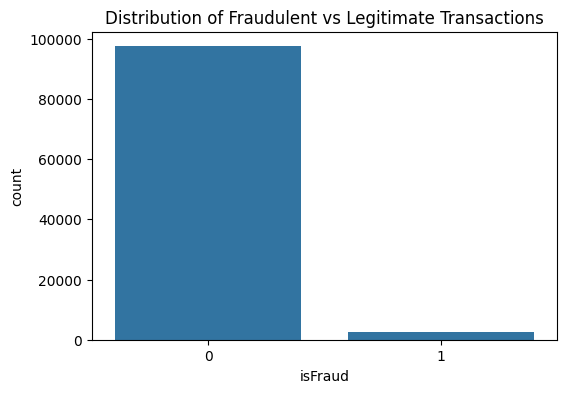

Fraud Percentage: 2.56%


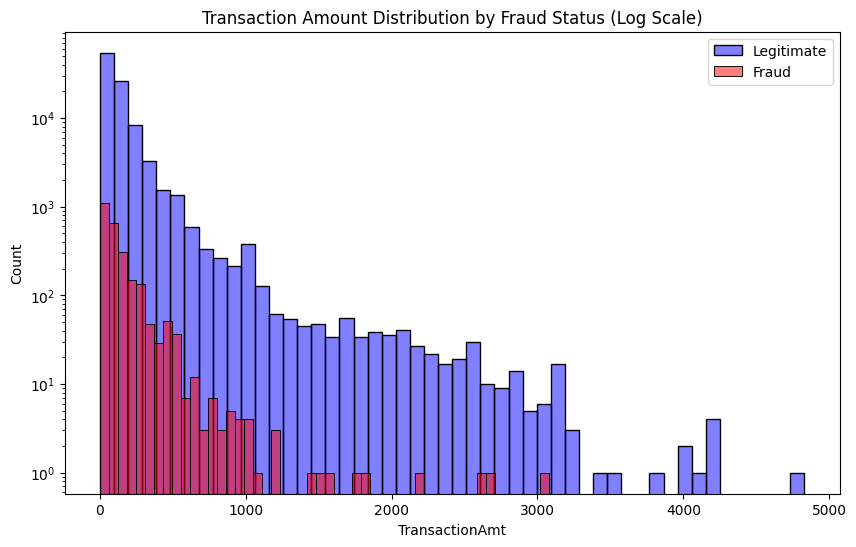

In [3]:
# Load Data
print("Loading data...")
# Loading a sample to avoid memory issues when exploring
train_transaction = pd.read_csv('train_transaction.csv', nrows=100000)
train_identity = pd.read_csv('train_identity.csv')

# Merge datasets
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
print(f"Dataset shape: {train.shape}")

# Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=train)
plt.title('Distribution of Fraudulent vs Legitimate Transactions')
plt.show()

print(f"Fraud Percentage: {(train['isFraud'].sum() / len(train)) * 100:.2f}%")

# Transaction amount analysis
plt.figure(figsize=(10, 6))
sns.histplot(train[train['isFraud'] == 0]['TransactionAmt'], bins=50, color='blue', alpha=0.5, label='Legitimate')
sns.histplot(train[train['isFraud'] == 1]['TransactionAmt'], bins=50, color='red', alpha=0.5, label='Fraud')
plt.title('Transaction Amount Distribution by Fraud Status (Log Scale)')
plt.yscale('log')
plt.legend()
plt.show()


## Phase 2: Engineering behavioral features (device ID, velocity, amounts)


In [4]:
# Handling missing values and categorical features for a subset
cols_to_use = ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'P_emaildomain', 'R_emaildomain', 'DeviceInfo', 'DeviceType']
df = train[[c for c in cols_to_use if c in train.columns]].copy()

# Feature: Transaction Velocity (Transactions per card in a certain time window)
df.sort_values('TransactionDT', inplace=True)

# Frequency of card1
if 'card1' in df.columns:
    df['card1_count'] = df.groupby('card1')['TransactionID'].transform('count')
    df['card1_amt_mean'] = df.groupby('card1')['TransactionAmt'].transform('mean')
    df['card1_amt_std'] = df.groupby('card1')['TransactionAmt'].transform('std')
    df['amt_to_mean_card1'] = df['TransactionAmt'] / (df['card1_amt_mean'] + 1e-5)

# Device Info features
if 'DeviceInfo' in df.columns:
    df['DeviceInfo'] = df['DeviceInfo'].fillna('unknown')
    df['device_name'] = df['DeviceInfo'].apply(lambda x: x.split('/')[0] if isinstance(x, str) else 'unknown')

# Label encoding for categorical columns
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'device_name', 'DeviceInfo']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# Fill missing numerical values with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("Feature engineering complete.")
df.head()


Feature engineering complete.


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,dist1,P_emaildomain,R_emaildomain,DeviceInfo,DeviceType,card1_count,card1_amt_mean,card1_amt_std,amt_to_mean_card1,device_name
0,2987000,0,86400,68.5,4,13926,387.0,150.0,1,142.0,...,19.0,48,49,864,2,6,93.083333,48.590551,0.735900,788
1,2987001,0,86401,29.0,4,2755,404.0,150.0,2,102.0,...,9.0,16,49,864,2,131,243.244504,446.483280,0.119222,788
2,2987002,0,86469,59.0,4,4663,490.0,150.0,4,166.0,...,287.0,35,49,864,2,132,86.119621,85.564662,0.685094,788
3,2987003,0,86499,50.0,4,18132,567.0,150.0,2,117.0,...,9.0,54,49,864,2,623,112.899968,177.192403,0.442870,788
4,2987004,0,86506,50.0,1,4497,514.0,150.0,2,102.0,...,9.0,16,49,423,1,2,40.000000,14.142136,1.250000,380


## Phase 3: Implementing Isolation Forest and Ensemble models


In [5]:
# Prepare features and target
X = df.drop(['TransactionID', 'isFraud', 'TransactionDT'], axis=1, errors='ignore')
y = df['isFraud']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Isolation Forest...")
iso_forest = IsolationForest(n_estimators=100, contamination=0.035, random_state=42, n_jobs=-1)
iso_forest.fit(X_train)

# Isolation Forest predictions (-1 for anomalies, 1 for normal)
iso_preds_test = iso_forest.predict(X_test)

# Convert predictions to 0 (normal) and 1 (anomaly/fraud)
iso_preds_test_binary = [1 if x == -1 else 0 for x in iso_preds_test]

print("Isolation Forest Classification Report:")
print(classification_report(y_test, iso_preds_test_binary))

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds))
print(f"ROC AUC: {roc_auc_score(y_test, rf_probs):.4f}")

# Ensemble: Voting Classifier
print("Training Voting Classifier (Ensemble)...")
rf1 = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
rf2 = RandomForestClassifier(n_estimators=100, max_depth=12, max_features='log2', class_weight='balanced', random_state=42, n_jobs=-1)

ensemble = VotingClassifier(estimators=[('rf1', rf1), ('rf2', rf2)], voting='soft')
ensemble.fit(X_train, y_train)

ens_preds = ensemble.predict(X_test)
ens_probs = ensemble.predict_proba(X_test)[:, 1]

print("Ensemble Classification Report:")
print(classification_report(y_test, ens_preds))
print(f"Ensemble ROC AUC: {roc_auc_score(y_test, ens_probs):.4f}")


Training Isolation Forest...
Isolation Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     19488
           1       0.06      0.08      0.07       512

    accuracy                           0.94     20000
   macro avg       0.52      0.52      0.52     20000
weighted avg       0.95      0.94      0.95     20000

Training Random Forest...
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     19488
           1       0.16      0.62      0.26       512

    accuracy                           0.91     20000
   macro avg       0.58      0.77      0.60     20000
weighted avg       0.97      0.91      0.93     20000

ROC AUC: 0.8696
Training Voting Classifier (Ensemble)...
Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     19488
           1    

## Phase 4: Simulation of real-time stream processing


In [6]:
# Simulate a real-time transaction stream
def stream_processor(model, data_stream, batch_size=10):
    stream_results = []

    print(f"Starting real-time processing simulation (batch size: {batch_size})...")
    for i in range(0, len(data_stream), batch_size):
        batch = data_stream.iloc[i:i+batch_size]

        # Simulate processing time
        start_time = time.time()

        # Score the batch
        probs = model.predict_proba(batch)[:, 1]
        preds = model.predict(batch)

        process_time = time.time() - start_time

        for j, (prob, pred) in enumerate(zip(probs, preds)):
            stream_results.append({
                'batch_id': i // batch_size,
                'tx_index': i + j,
                'fraud_probability': prob,
                'is_flagged': pred,
                'process_time_ms': process_time * 1000 / len(batch)
            })

        # Add slight delay to simulate actual streaming
        time.sleep(0.01)

        if i >= batch_size * 5: # Stop after a few batches for demonstration
            break

    return pd.DataFrame(stream_results)

# Take a small sample of test data to stream
stream_sample = X_test.head(50)
stream_results_df = stream_processor(ensemble, stream_sample)

print("\nStream Processing Output Head:")
display(stream_results_df.head(10))


Starting real-time processing simulation (batch size: 10)...

Stream Processing Output Head:


,batch_id,tx_index,fraud_probability,is_flagged,process_time_ms
0,0,0,0.277835,0,14.880443
1,0,1,0.226897,0,14.880443
2,0,2,0.135393,0,14.880443
3,0,3,0.210543,0,14.880443
4,0,4,0.245064,0,14.880443
5,0,5,0.450518,0,14.880443
6,0,6,0.156639,0,14.880443
7,0,7,0.889171,1,14.880443
8,0,8,0.165529,0,14.880443
9,0,9,0.171827,0,14.880443


## Phase 5: KPI reporting focused on total fraud savings impact


In [7]:
# Calculate Business KPIs
# Calculate Confusion Matrix for Ensemble on full test set
cm = confusion_matrix(y_test, ens_preds)
tn, fp, fn, tp = cm.ravel()

# Total actual fraud transactions
actual_fraud_txs = y_test.sum()
total_fraud_value = X_test[y_test == 1]['TransactionAmt'].sum()

# Value of fraud caught (True Positives)
fraud_caught_value = X_test[(y_test == 1) & (ens_preds == 1)]['TransactionAmt'].sum()

# Value of false positive interventions (cost of manual review or customer friction)
# Assuming a $5 operational cost per false positive review
cost_per_review = 5.0
false_positive_cost = fp * cost_per_review

# Net Savings
net_savings = fraud_caught_value - false_positive_cost

print("="*40)
print("FRAUD DETECTION SYSTEM KPI REPORT")
print("="*40)
print(f"Total Transactions Processed: {len(y_test):,}")
print(f"Total Actual Fraud Transactions: {actual_fraud_txs:,}")
print(f"Total Fraud Value Exposure: ${total_fraud_value:,.2f}")
print("-" * 40)
print(f"Fraud Transactions Blocked (TP): {tp:,}")
print(f"False Positives (Customer Friction): {fp:,}")
print(f"Missed Fraud (FN): {fn:,}")
print("-" * 40)
print(f"Gross Fraud Savings: ${fraud_caught_value:,.2f}")
print(f"Operational Cost (False Positives): ${false_positive_cost:,.2f}")
print(f"NET FRAUD SAVINGS: ${net_savings:,.2f}")
print(f"Fraud Capture Rate (Recall): {(tp / actual_fraud_txs) * 100:.2f}%" if actual_fraud_txs > 0 else "N/A")
print(f"ROI on Fraud System (Savings/Cost): {fraud_caught_value / false_positive_cost:.2f}x" if false_positive_cost > 0 else "N/A")
print("="*40)


FRAUD DETECTION SYSTEM KPI REPORT
Total Transactions Processed: 20,000
Total Actual Fraud Transactions: 512
Total Fraud Value Exposure: $73,644.71
----------------------------------------
Fraud Transactions Blocked (TP): 322
False Positives (Customer Friction): 1,555
Missed Fraud (FN): 190
----------------------------------------
Gross Fraud Savings: $44,955.37
Operational Cost (False Positives): $7,775.00
NET FRAUD SAVINGS: $37,180.37
Fraud Capture Rate (Recall): 62.89%
ROI on Fraud System (Savings/Cost): 5.78x
